In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# VGG16
import keras
from keras.applications import EfficientNetB0, ResNet50, MobileNetV2, VGG16
from keras.models import Sequential, Model
from keras.layers import Dense, GlobalAveragePooling2D, Average, Concatenate

In [2]:
# Load drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Data Paths
# Physiological data paths
phys_data_15 = '/content/drive/MyDrive/stress_classification/PhysiologicalSignals/physiological_signals_20_15sn-1HUo9x.csv'
phys_data_30 = '/content/drive/MyDrive/stress_classification/PhysiologicalSignals/physiological_signals_20_30sn-TantMU.csv'
phys_data_60 = '/content/drive/MyDrive/stress_classification/PhysiologicalSignals/physiological_signals_20_1dk-zg22vg.csv'

# Facial expressions data Paths
expr_data_2c = '/content/drive/MyDrive/stress_classification/TheFacialExpressions/facial_dataset_2_class.csv'

# Number of LSTM memory units
UNITS = 64

### Data Preprocessing

In [4]:
# Load Dataset
def load_data(path):
  df = pd.read_csv(path)
  data = df[df['emotion'] != 2]

  # Print the DataFrame
  print(len(data))
  print(data)

  return data

In [5]:
# Data preprocessing LSTM

def data_preprocessing_lstm(data):
  # Separate features (x) and labels (y)
  x = data.drop('emotion', axis=1).values
  y = data['emotion'].values

  print("Raw Data:")
  print(x[:5])
  print(y[:5])
  print('\n')
# Data size
  fusion_data_size=7000
  test_size=3000
  # Split the data into training and testing sets
  x_train, x_fusion_test, y_train, y_fusion_test = train_test_split(x, y, test_size=(fusion_data_size + test_size), random_state=42)
  x_fusion, x_test, y_fusion, y_test = train_test_split(x_fusion_test, y_fusion_test, test_size=(test_size / (fusion_data_size + test_size)), random_state=42)
  # Data normalization
  scaler = StandardScaler()
  x_train = scaler.fit_transform(x_train)
  x_fusion = scaler.fit_transform(x_fusion)
  x_test = scaler.transform(x_test)

  print("Transformed data:")
  print("Features(x): "+str(x_train[:5]))
  print("Label(y): "+str(y_train[:5]))
  print('------------------------------------')
  print("Classes: "+ str(np.unique(y)))
  print("Number of Training data: " + str(len(x_train)))
  print("Number of Fusion data: " + str(len(x_fusion)))
  print("Number of Test data: " + str(len(x_test)))

  return x_train, y_train, x_fusion, y_fusion, x_test, y_test

In [6]:
# Create sequences from the data
def create_sequences(data, sequence_length):
    sequences = []
    labels = []
    for i in range(len(data) - sequence_length + 1):
        #temp = data
        #print(temp)
        seq = data[i:i+sequence_length,:-1]
        label = data[i+sequence_length-1, -1]
        sequences.append(seq)
        labels.append(label)
    print(sequences[1])
    return np.array(sequences), np.array(labels)

In [7]:
# Load data LSTM
data_lstm = load_data(phys_data_60)

167040
         eda     bvp   temp   x   y   z  emotion
0       0.00   -0.03  31.63 -13 -18  62        0
1       0.04    5.06  31.63 -15 -18  62        0
2       0.08   17.91  31.63 -14 -17  62        0
3       0.08   79.34  31.63 -16 -17  60        0
4       0.08  228.25  31.63   3 -12  63        0
...      ...     ...    ...  ..  ..  ..      ...
167995  0.33  -35.69  36.05 -53  23  16        1
167996  0.35  291.37  36.11 -66  23   1        1
167997  0.35  -99.97  36.11 -63  19  -8        1
167998  0.35  -48.63  36.11 -61  22 -10        1
167999  0.34   59.01  36.11 -61  20 -10        1

[167040 rows x 7 columns]


In [8]:
# Train, valid, test split - LSTM data
x_train, y_train, x_fusion, y_fusion, x_test, y_test = data_preprocessing_lstm(data_lstm)

Raw Data:
[[ 0.0000e+00 -3.0000e-02  3.1630e+01 -1.3000e+01 -1.8000e+01  6.2000e+01]
 [ 4.0000e-02  5.0600e+00  3.1630e+01 -1.5000e+01 -1.8000e+01  6.2000e+01]
 [ 8.0000e-02  1.7910e+01  3.1630e+01 -1.4000e+01 -1.7000e+01  6.2000e+01]
 [ 8.0000e-02  7.9340e+01  3.1630e+01 -1.6000e+01 -1.7000e+01  6.0000e+01]
 [ 8.0000e-02  2.2825e+02  3.1630e+01  3.0000e+00 -1.2000e+01  6.3000e+01]]
[0 0 0 0 0]


Transformed data:
Features(x): [[-0.3679673   0.10775534 -1.40301738 -1.18053045 -0.68571129  1.05922847]
 [-0.23972122  0.58395848  0.77407979 -1.71486909 -0.1048099   0.7382769 ]
 [-0.24309612  0.58165264  0.37995013  0.50263627  0.47609148  0.86665753]
 [-0.30721916 -1.09884732  0.34241398  0.74308866 -0.4823958   0.80246722]
 [ 0.58037872 -0.04885767 -0.04233164 -1.71486909 -0.91807184 -1.7972405 ]]
Label(y): [0 1 0 0 1]
------------------------------------
Classes: [0 1]
Number of Training data: 157040
Number of Fusion data: 7000
Number of Test data: 3000


In [9]:
# Sequence length
sequence_length = 1
# Create sequences for training and testing for LSTM
x_train_lstm, y_train_lstm = create_sequences(np.column_stack((x_train, y_train)), sequence_length)
x_fusion_lstm, y_fusion_lstm = create_sequences(np.column_stack((x_fusion, y_fusion)), sequence_length)
x_test_lstm, y_test_lstm = create_sequences(np.column_stack((x_test, y_test)), sequence_length)

[[-0.23972122  0.58395848  0.77407979 -1.71486909 -0.1048099   0.7382769 ]]
[[-0.01867953  0.75354608 -0.56439823  0.88623636 -1.54679402 -0.99931533]]
[[-0.33033943 -2.69050859 -1.64154304 -0.69814395  1.65653077 -0.26210048]]


In [10]:
# Load data for VGG model
data_vgg = load_data(expr_data_2c)

30520
       emotion                                             pixels       Usage
0            0  77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...    Training
1            0  85 84 90 121 101 102 133 153 153 169 177 189 1...    Training
2            0  4 2 13 41 56 62 67 87 95 62 65 70 80 107 127 1...    Training
3            0  107 107 109 109 109 109 110 101 123 140 144 14...    Training
4            0  14 14 18 28 27 22 21 30 42 61 77 86 88 95 100 ...    Training
...        ...                                                ...         ...
30515        1  90 77 65 57 60 54 58 36 44 35 20 26 30 25 57 1...  PublicTest
30516        1  210 210 209 201 202 207 208 206 198 186 165 13...  PublicTest
30517        1  86 91 82 59 50 54 51 43 36 39 22 26 22 22 41 9...  PublicTest
30518        1  201 199 196 192 188 187 156 99 81 77 77 86 99 ...  PublicTest
30519        1  184 183 162 90 63 62 51 51 46 34 29 26 31 36 3...  PublicTest

[30520 rows x 3 columns]


In [11]:
# Data preprocessing - VGG
def pixel_transform(data):
  # Extract pixel data and convert it to numpy array
  pixel_data = data['pixels'].apply(lambda x: np.array(x.split(), dtype="float32"))
  pixels = np.vstack(pixel_data.values)
  pixels = pixels.reshape(-1, 48, 48, 1)  # assuming grayscale images

  # Extract emotion labels
  emotions = data['emotion'].values

  # Classes
  total_classes = len(np.unique(emotions))
  print("Classes: " + str(np.unique(emotions)) + "total_classes: " + str(total_classes))

  return pixels, emotions

In [12]:
def preprocess_data_vgg(pixels, emotions):
  fusion_data_size=7000
  test_size=3000
  # Preprocess the data
  pixels /= 255.0  # normalize pixel values between 0 and 1
  le = LabelEncoder()
  emotions = le.fit_transform(emotions)
  emotions = to_categorical(emotions)

  # Split the data into training, validation and testing sets
  x_train, x_val_test, y_train, y_val_test = train_test_split(pixels, emotions, test_size=(fusion_data_size + test_size), random_state=42)
  x_fusion, x_test, y_fusion, y_test = train_test_split(x_val_test, y_val_test, test_size=(test_size / (fusion_data_size + test_size)), random_state=42)

  print("Normalized Data (pixels): " + str(pixels[1]))
  print("\nTraining data: " + str(len(x_train)))
  print("Validation data: " + str(len(x_fusion)))
  print("Test data: " + str(len(x_test)))

  # # Classes
  # total_classes = len(np.unique(emotions))
  # print("Classes: " + str(np.unique(emotions)) + "total_classes: " + str(total_classes))

  return x_train, x_fusion,x_test, y_train, y_fusion, y_test

In [13]:
pixels, emotions = pixel_transform(data_vgg)
x_train_temp,x_fusion_temp,x_test_temp,y_train_vgg,y_fusion_vgg,y_test_vgg = preprocess_data_vgg(pixels,emotions)

# Convert pixel data to 3 channels (VGG16 expects 3 channels)
x_train_vgg = np.stack([x_train_temp[:, :, :, 0]] * 3, axis=-1)
x_fusion_vgg = np.stack([x_fusion_temp[:, :, :, 0]] * 3, axis=-1)
x_test_vgg = np.stack([x_test_temp[:, :, :, 0]] * 3, axis=-1)

Classes: [0 1]total_classes: 2
Normalized Data (pixels): [[[0.33333334]
  [0.32941177]
  [0.3529412 ]
  ...
  [0.15686275]
  [0.18039216]
  [0.24705882]]

 [[0.30588236]
  [0.29803923]
  [0.39607844]
  ...
  [0.14117648]
  [0.17254902]
  [0.20392157]]

 [[0.29803923]
  [0.3764706 ]
  [0.4509804 ]
  ...
  [0.13333334]
  [0.16470589]
  [0.16862746]]

 ...

 [[0.4       ]
  [0.39215687]
  [0.38039216]
  ...
  [0.25490198]
  [0.29803923]
  [0.24313726]]

 [[0.41960785]
  [0.39607844]
  [0.3764706 ]
  ...
  [0.22352941]
  [0.30980393]
  [0.27450982]]

 [[0.41568628]
  [0.40392157]
  [0.36862746]
  ...
  [0.22745098]
  [0.28627452]
  [0.32941177]]]

Training data: 20520
Validation data: 7000
Test data: 3000


### Model Implementation

###### Fusion model- combining output

In [16]:
# Build the LSTM model
model_lstm = Sequential([
    LSTM(UNITS, input_shape=(x_train_lstm.shape[1], x_train_lstm.shape[2])),
    Dense(1, activation='sigmoid')
])
model_lstm.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 64)                18176     
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 18241 (71.25 KB)
Trainable params: 18241 (71.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [17]:
# Build VGG16 model
# Load the EfficientNetB0 model (include_top=False to exclude the fully connected layers)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(48, 48, 3))
model_vgg16 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax')
])
model_vgg16.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 global_average_pooling2d_1  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_4 (Dense)             (None, 128)               65664     
                                                                 
 dense_5 (Dense)             (None, 2)                 258       
                                                                 
Total params: 14780610 (56.38 MB)
Trainable params: 14780610 (56.38 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


##### Model Training

In [18]:
# Train LSTM model
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(x_train_lstm, y_train_lstm, epochs=30, batch_size=4, validation_split=0.2)

Epoch 1/30
31408/31408 [==============================] - 144s 4ms/step - loss: 0.6075 - accuracy: 0.6829 - val_loss: 0.5852 - val_accuracy: 0.6963
Epoch 2/30
31408/31408 [==============================] - 129s 4ms/step - loss: 0.5733 - accuracy: 0.7045 - val_loss: 0.5597 - val_accuracy: 0.7122
Epoch 3/30
31408/31408 [==============================] - 132s 4ms/step - loss: 0.5463 - accuracy: 0.7241 - val_loss: 0.5323 - val_accuracy: 0.7363
Epoch 4/30
31408/31408 [==============================] - 131s 4ms/step - loss: 0.5210 - accuracy: 0.7433 - val_loss: 0.5097 - val_accuracy: 0.7479
Epoch 5/30
31408/31408 [==============================] - 124s 4ms/step - loss: 0.5017 - accuracy: 0.7565 - val_loss: 0.4900 - val_accuracy: 0.7639
Epoch 6/30
31408/31408 [==============================] - 131s 4ms/step - loss: 0.4857 - accuracy: 0.7677 - val_loss: 0.4791 - val_accuracy: 0.7665
Epoch 7/30
31408/31408 [==============================] - 125s 4ms/step - loss: 0.4715 - accuracy: 0.7772 - val_

In [ ]:
# Train VGG16 model
model_vgg16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_vgg16.fit(x_train_vgg, y_train_vgg, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
129/129 [==============================] - 29s 137ms/step - loss: 0.9347 - accuracy: 0.5482 - val_loss: 0.6817 - val_accuracy: 0.5724
Epoch 2/10
129/129 [==============================] - 13s 103ms/step - loss: 0.6861 - accuracy: 0.5562 - val_loss: 0.6793 - val_accuracy: 0.5724
Epoch 3/10
129/129 [==============================] - 13s 102ms/step - loss: 0.6834 - accuracy: 0.5627 - val_loss: 0.6760 - val_accuracy: 0.5887
Epoch 4/10
129/129 [==============================] - 13s 102ms/step - loss: 0.5630 - accuracy: 0.7082 - val_loss: 0.5252 - val_accuracy: 0.7580
Epoch 5/10
129/129 [==============================] - 14s 105ms/step - loss: 0.4277 - accuracy: 0.8028 - val_loss: 0.4123 - val_accuracy: 0.8036
Epoch 6/10
129/129 [==============================] - 13s 104ms/step - loss: 0.3670 - accuracy: 0.8369 - val_loss: 0.3968 - val_accuracy: 0.8202
Epoch 7/10
129/129 [==============================] - 13s 104ms/step - loss: 0.3260 - accuracy: 0.8587 - val_loss: 0.3664 - val_ac

In [ ]:
model_lstm.save('/content/drive/MyDrive/stress_classification/stress_analysis_multimodal/models_lstm_vgg16/lstm60s.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
model_vgg16.save('/content/drive/MyDrive/stress_classification/stress_analysis_multimodal/models_lstm_vgg16/vgg162sv2.h5')

In [19]:
# Load model
model_vgg16.load_weights('/content/drive/MyDrive/stress_classification/stress_analysis_multimodal/models_lstm_vgg16/vgg162sv2.h5')

##### Fusion model- combining features

In [20]:
# Extract features from the LSTM model
intermediate_layer_model_lstm = Model(inputs=model_lstm.input, outputs=model_lstm.layers[-2].output)

In [21]:
# Extract features from the VGG16 model
intermediate_layer_model_vgg16 = Model(inputs=model_vgg16.input, outputs=model_vgg16.layers[-3].output)

In [22]:
def intermediate_predictions(model_lstm, model_vgg16, x_lstm,x_vgg,y_lstm,y_vgg):
  # Make predictions using both models
  predictions_lstm = model_lstm.predict(x_lstm)
  predictions_vgg16 = model_vgg16.predict(x_vgg)

  # Concatenate predictions
  combined_predictions = np.concatenate([predictions_lstm, predictions_vgg16], axis=1)

  # Reshape y_fusion_vgg if necessary
  if len(y_vgg.shape) > 1:
      y_vgg = y_vgg[:, 0]
  # Combine labels from both models using logical OR operation
  combined_labels = np.logical_or(y_lstm, y_vgg).astype(int)
  # Check the shape of combined predictions and combined labels
  print("Shape of combined predictions:", combined_predictions.shape)
  print("Shape of combined labels:", combined_labels.shape)

  return combined_predictions, combined_labels


In [23]:
# For output predictions
#combined_predictions, combined_labels = intermediate_predictions(model_lstm,model_vgg16,x_fusion_lstm,x_fusion_vgg,y_fusion_lstm,y_fusion_vgg)

# For features prediction
combined_predictions, combined_labels = intermediate_predictions(intermediate_layer_model_lstm,intermediate_layer_model_vgg16,x_fusion_lstm,x_fusion_vgg,y_fusion_lstm,y_fusion_vgg)

219/219 [==============================] - 5s 13ms/step
Shape of combined predictions: (7000, 576)
Shape of combined labels: (7000,)


##### Combining Models

In [24]:
# Define input layer for concatenated predictions
input_shape = combined_predictions.shape[1]
input_combined = Input(shape=(input_shape,))
print(input_shape)

# Define fusion layers
dense_1 = Dense(128, activation='relu')(input_combined)
dropout = Dropout(0.5)(dense_1)
output = Dense(1, activation='sigmoid')(dropout)  # Binary classification, so output has one unit with sigmoid activation

# Create fusion model
fusion_model = Model(inputs=input_combined, outputs=output)

# Compile fusion model
fusion_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

fusion_model.summary()

576
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 576)]             0         
                                                                 
 dense_6 (Dense)             (None, 128)               73856     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 73985 (289.00 KB)
Trainable params: 73985 (289.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [25]:
# Train fusion model
history_fusion = fusion_model.fit(combined_predictions, combined_labels, epochs=10, batch_size=128, validation_split=0.15)

Epoch 1/10
47/47 [==============================] - 2s 7ms/step - loss: 0.5362 - accuracy: 0.7005 - val_loss: 0.4762 - val_accuracy: 0.7495
Epoch 2/10
47/47 [==============================] - 0s 4ms/step - loss: 0.4893 - accuracy: 0.7385 - val_loss: 0.4683 - val_accuracy: 0.7590
Epoch 3/10
47/47 [==============================] - 0s 4ms/step - loss: 0.4810 - accuracy: 0.7487 - val_loss: 0.4654 - val_accuracy: 0.7762
Epoch 4/10
47/47 [==============================] - 0s 4ms/step - loss: 0.4712 - accuracy: 0.7560 - val_loss: 0.4664 - val_accuracy: 0.7552
Epoch 5/10
47/47 [==============================] - 0s 4ms/step - loss: 0.4718 - accuracy: 0.7587 - val_loss: 0.4532 - val_accuracy: 0.7848
Epoch 6/10
47/47 [==============================] - 0s 4ms/step - loss: 0.4651 - accuracy: 0.7649 - val_loss: 0.4515 - val_accuracy: 0.7695
Epoch 7/10
47/47 [==============================] - 0s 4ms/step - loss: 0.4579 - accuracy: 0.7734 - val_loss: 0.4452 - val_accuracy: 0.7914
Epoch 8/10
47/47 [==

In [26]:
fusion_model.save('/content/drive/MyDrive/stress_classification/stress_analysis_multimodal/models_fusion_features/lstm60s_vgg162s.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Model Evaluation

In [27]:
def plot_acc_loss(history):
  # Plot training and validation accuracy
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

  # Plot training and validation loss
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

In [28]:
def evaluate_model(fusion_model,model_lstm,model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg):
  # Make predictions on the test data
  combined_predictions_test, combined_labels_test = intermediate_predictions(model_lstm,model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)
  test_predictions = fusion_model.predict(combined_predictions_test)

  # Convert probabilities to binary labels (assuming binary classification)
  binary_predictions = (test_predictions > 0.5).astype(int)

  # Confusion matrix
  conf_matrix = confusion_matrix(combined_labels_test, binary_predictions)
  plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.colorbar()
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  # Classification report
  class_report = classification_report(combined_labels_test, binary_predictions)
  print("Classification Report:")
  print(class_report)

#### Fusion model Evaluation - Output predictions are combined

###### fusion output - lstm 15sdata - vgg16

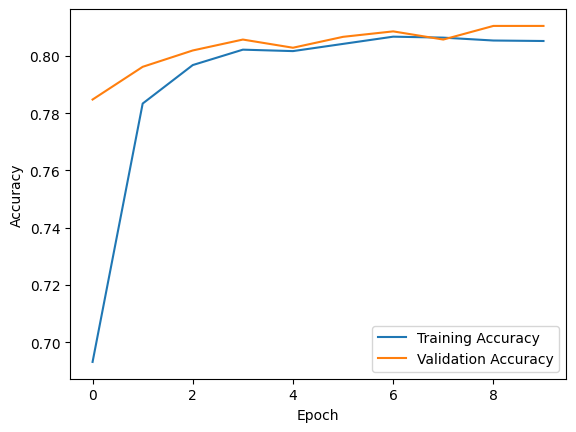

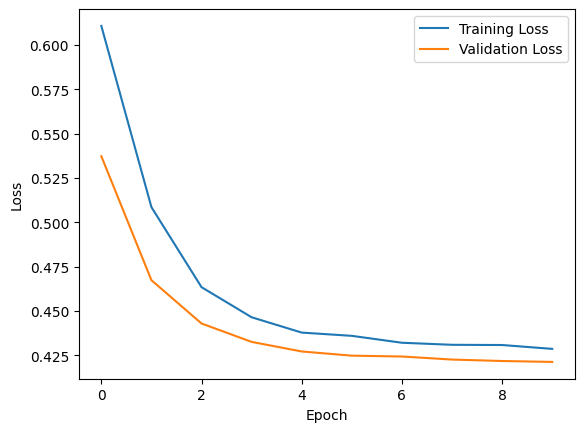

In [ ]:
plot_acc_loss(history_fusion)

94/94 [==============================] - 1s 11ms/step
Shape of combined predictions: (3000, 3)
Shape of combined labels: (3000,)
94/94 [==============================] - 0s 1ms/step


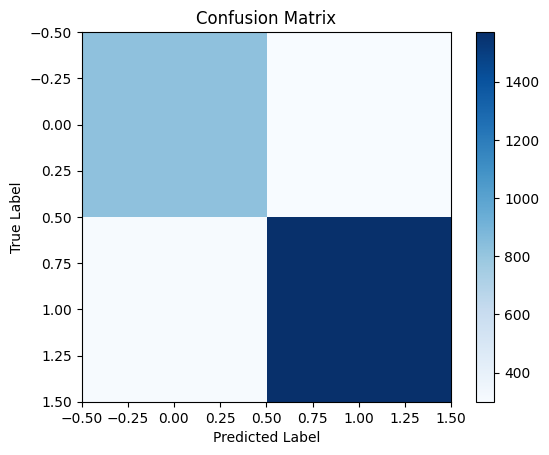

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1121
           1       0.84      0.84      0.84      1879

    accuracy                           0.80      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.80      0.80      0.80      3000



In [ ]:
evaluate_model(fusion_model,model_lstm,model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)

###### fusion output - lstm 30s - vgg16

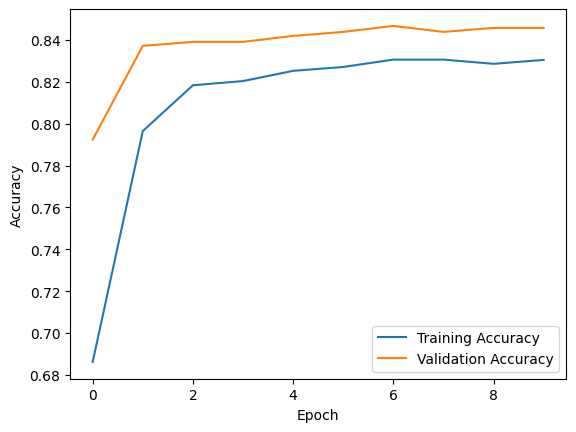

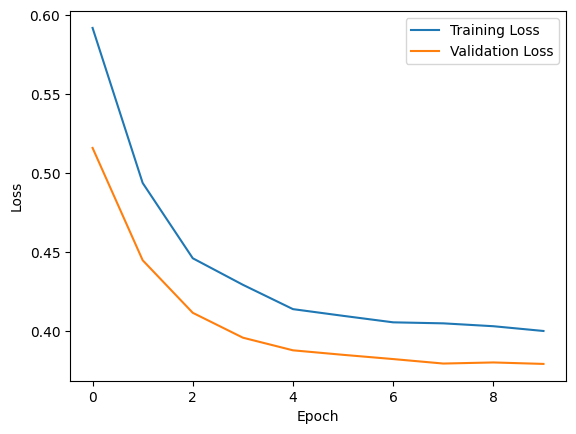

In [ ]:
plot_acc_loss(history_fusion)

94/94 [==============================] - 1s 11ms/step
Shape of combined predictions: (3000, 3)
Shape of combined labels: (3000,)
94/94 [==============================] - 0s 1ms/step


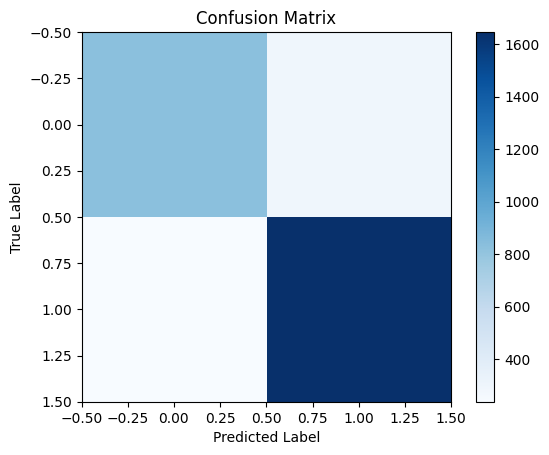

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76      1117
           1       0.85      0.87      0.86      1883

    accuracy                           0.82      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.82      0.82      0.82      3000



In [ ]:
evaluate_model(fusion_model,model_lstm,model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)

###### fusion output - lstm 60s - vgg16

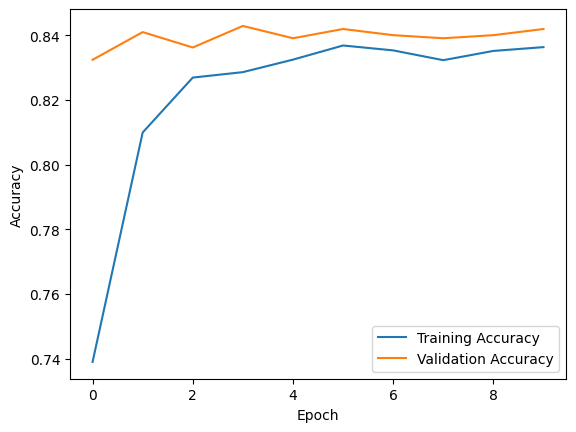

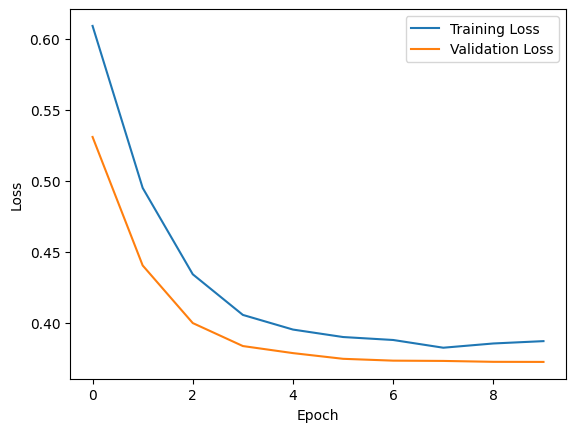

In [ ]:
plot_acc_loss(history_fusion)

94/94 [==============================] - 1s 11ms/step
Shape of combined predictions: (3000, 3)
Shape of combined labels: (3000,)
94/94 [==============================] - 0s 1ms/step


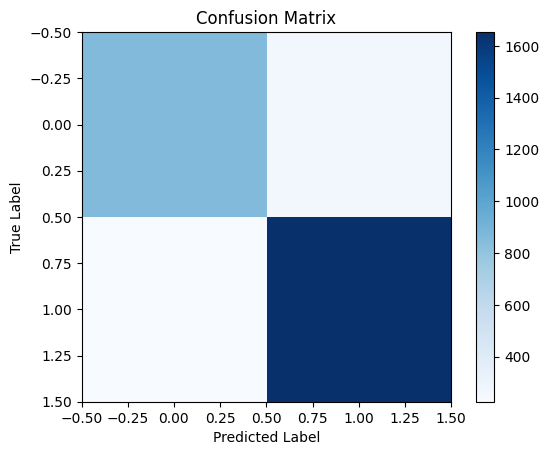

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78      1121
           1       0.86      0.88      0.87      1879

    accuracy                           0.84      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.84      0.84      0.84      3000



In [ ]:
evaluate_model(fusion_model,model_lstm,model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)

#### Fusion Model Evaluation - Output features are combined

##### fusion features - lstm 15s - vgg16

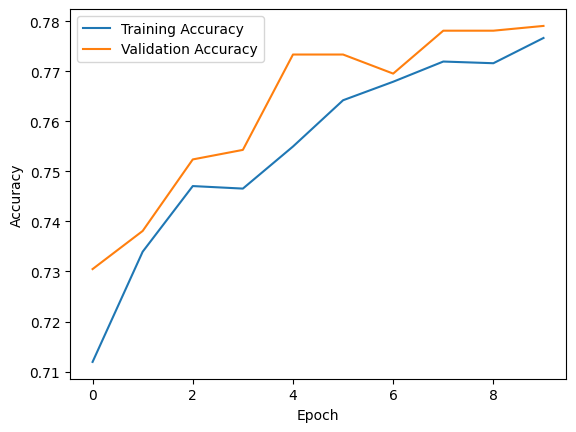

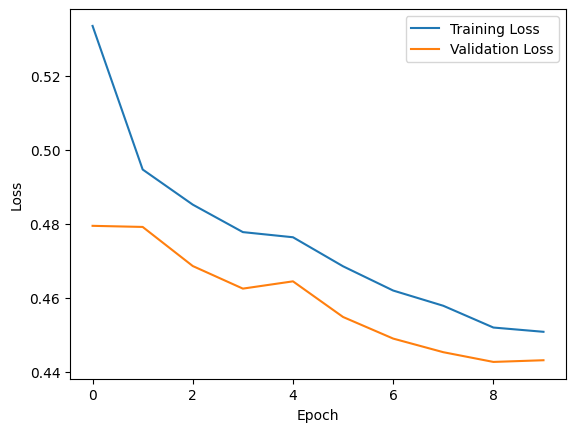

In [ ]:
plot_acc_loss(history_fusion)

94/94 [==============================] - 1s 10ms/step
Shape of combined predictions: (3000, 576)
Shape of combined labels: (3000,)
94/94 [==============================] - 0s 1ms/step


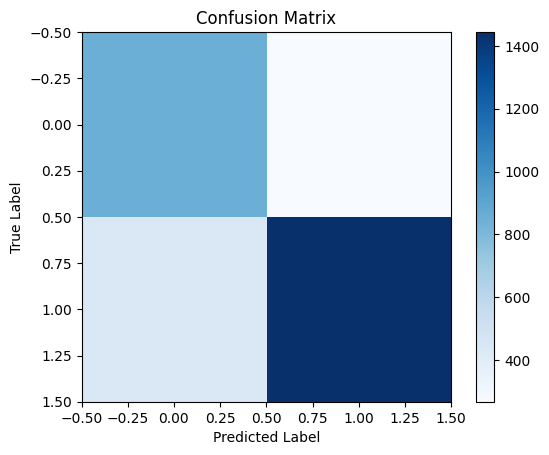

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.76      0.71      1121
           1       0.84      0.77      0.80      1879

    accuracy                           0.77      3000
   macro avg       0.75      0.77      0.76      3000
weighted avg       0.78      0.77      0.77      3000



In [ ]:
evaluate_model(fusion_model,intermediate_layer_model_lstm,intermediate_layer_model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)

##### fusion features - lstm 30s - vgg16 2s

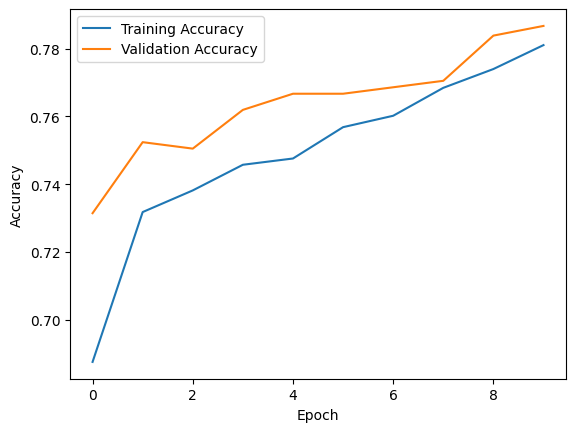

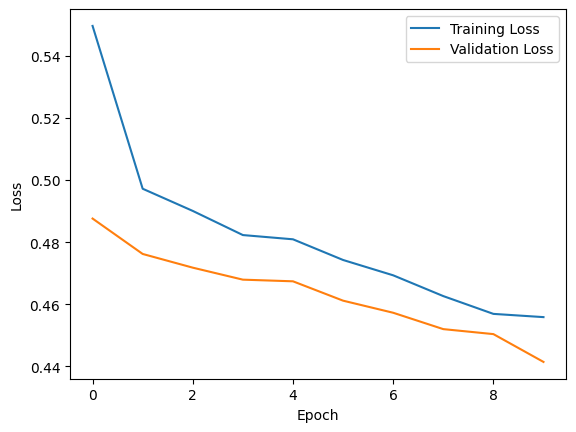

In [ ]:
plot_acc_loss(history_fusion)

94/94 [==============================] - 1s 10ms/step
Shape of combined predictions: (3000, 576)
Shape of combined labels: (3000,)
94/94 [==============================] - 0s 1ms/step


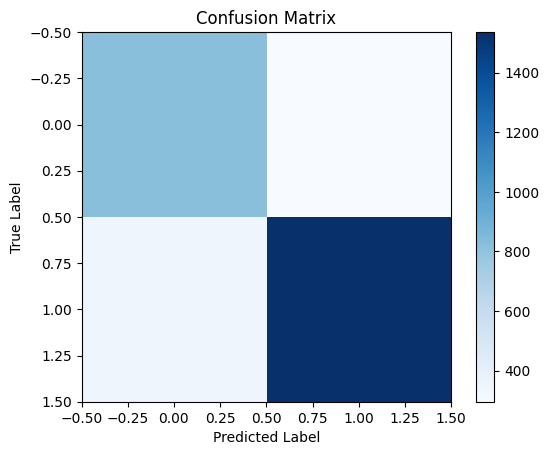

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      1117
           1       0.84      0.82      0.83      1883

    accuracy                           0.79      3000
   macro avg       0.77      0.78      0.77      3000
weighted avg       0.79      0.79      0.79      3000



In [ ]:
evaluate_model(fusion_model,intermediate_layer_model_lstm,intermediate_layer_model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)

##### fusion features - lstm 60s - vgg16 2s

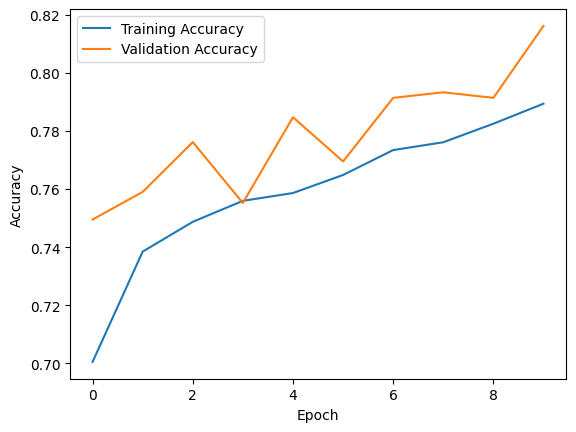

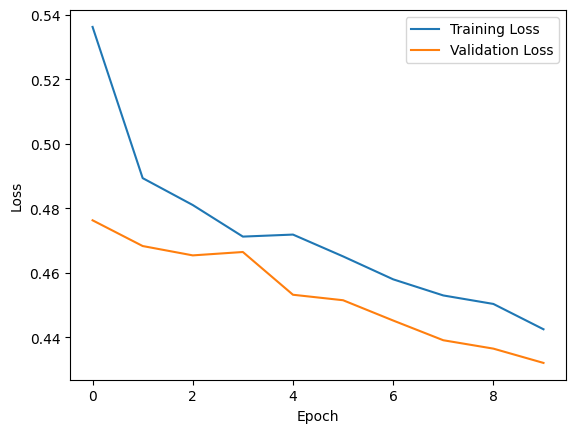

In [29]:
plot_acc_loss(history_fusion)

94/94 [==============================] - 1s 10ms/step
Shape of combined predictions: (3000, 576)
Shape of combined labels: (3000,)
94/94 [==============================] - 0s 2ms/step


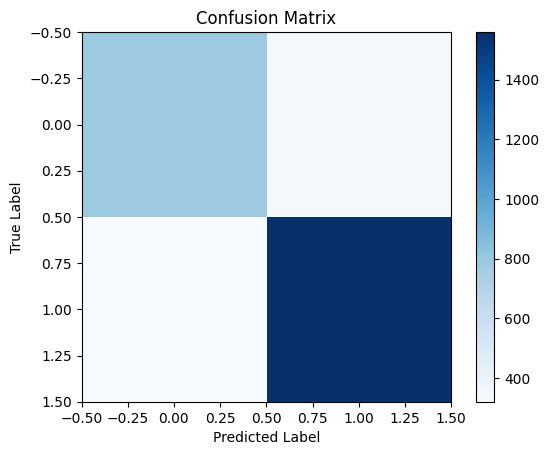

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.70      1121
           1       0.82      0.83      0.83      1879

    accuracy                           0.78      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.78      0.78      0.78      3000



In [30]:
evaluate_model(fusion_model,intermediate_layer_model_lstm,intermediate_layer_model_vgg16,x_test_lstm,x_test_vgg,y_test_lstm,y_test_vgg)